# Machine Learning Algorithms: A Practical Guide for Students

Welcome to this hands-on tutorial! In this notebook, you will learn how to use `scikit-learn` to implement and compare three powerful machine learning algorithms for classification tasks: **Decision Trees**, **Random Forests**, and **Boosting** methods.

We will focus on practical application: how to use the code, understand key parameters, and evaluate model performance. No complex math or theory required!

# Machine Learning Algorithms: Instructor Solution Guide

This notebook is the instructor's version, providing teaching notes, common student pitfalls, and model solutions for the exercises presented in the student tutorial. It mirrors the student notebook's structure, focusing on practical `scikit-learn` implementation of Decision Trees, Random Forests, and Boosting for classification tasks.

**Purpose:** To assist instructors in guiding students through the practical aspects of these algorithms, understanding key parameters, and evaluating model performance without delving into complex mathematical theory.

---

## 1. Setup and Data Preparation

**Teaching Notes:**
- **Reproducibility:** Emphasize the importance of `random_state` in `train_test_split` and model initializations for consistent results across runs. This is crucial for debugging and comparing student work.
- **Stratified Split:** Explain why `stratify=y` is vital for classification, especially with imbalanced datasets, to ensure that both training and testing sets have a representative proportion of each class.
- **Dataset Choice:** The Breast Cancer dataset is excellent for beginners due to its clear binary classification nature and manageable size.
- **Library Imports:** Briefly review the purpose of each imported library (pandas for data handling, numpy for numerical operations, matplotlib/seaborn for visualization, scikit-learn for ML models, xgboost for advanced boosting).


## 1. Setup and Data Preparation

First, let's import the necessary libraries and load a dataset. We will use the **Breast Cancer Wisconsin (Diagnostic) dataset**, a classic dataset for binary classification.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# XGBoost
import xgboost as xgb

# Set plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100 # Higher resolution for plots

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the Breast Cancer dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

print(f"Dataset shape: {X.shape}")
print(f"Target classes: {cancer.target_names}")
print(f"Number of features: {len(cancer.feature_names)}")

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Dataset shape: (569, 30)
Target classes: ['malignant' 'benign']
Number of features: 30

Training set size: 455 samples
Testing set size: 114 samples


## 2. Decision Trees for Classification

**Teaching Notes:**
- **Intuition:** Start by explaining Decision Trees as a series of if-else questions, making them highly interpretable.
- **Overfitting Risk:** Highlight early that Decision Trees are prone to overfitting, especially when allowed to grow too deep. This sets the stage for parameter tuning and ensemble methods.
- **`plot_tree`:** Demonstrate how `plot_tree` helps visualize the decision process, making the algorithm's behavior transparent.


## 2. Decision Trees for Classification

Decision Trees are fundamental building blocks in machine learning. They make decisions by asking a series of questions about the data. Let's see how to use `DecisionTreeClassifier`.

### 2.1 Basic Decision Tree

We'll start with a basic Decision Tree and then explore its parameters.

In [ ]:
# Initialize a basic Decision Tree Classifier
dt_basic = DecisionTreeClassifier(random_state=42)

# Train the model
dt_basic.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt_basic = dt_basic.predict(X_test)

# Evaluate the model
accuracy_dt_basic = accuracy_score(y_test, y_pred_dt_basic)
print(f"Basic Decision Tree Accuracy: {accuracy_dt_basic:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_basic, target_names=cancer.target_names))

Basic Decision Tree Accuracy: 0.9123

Classification Report:
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



### 2.2 Exploring Key Parameters of Decision Trees

**Teaching Notes:**
- **`max_depth`:** Explain this as the primary control for tree complexity. A deeper tree can capture more complex patterns but risks memorizing the training data (overfitting). A shallow tree might underfit.
- **`min_samples_split` / `min_samples_leaf`:** These parameters prevent the tree from making splits on very small groups of samples, which often leads to noisy, ungeneralizable rules. Higher values lead to simpler, more robust trees.
- **`criterion` (gini/entropy):** Briefly explain that these are metrics used to decide the 'best' split. Gini impurity is often slightly faster to compute and is the default. The practical difference in performance is usually minimal.
- **Common Pitfall:** Students often ignore these parameters, leading to highly overfit trees that perform poorly on new data. Emphasize that default settings are rarely optimal.


### 2.2 Exploring Key Parameters of Decision Trees

Decision Trees can easily overfit the training data if not constrained. Here are some important parameters to control their complexity:

- `max_depth`: The maximum depth of the tree. A smaller value prevents the tree from becoming too deep and complex.
- `min_samples_split`: The minimum number of samples required to split an internal node. Higher values prevent splitting on small groups.
- `min_samples_leaf`: The minimum number of samples required to be at a leaf node. Similar to `min_samples_split`, it controls the size of leaf nodes.
- `criterion`: The function to measure the quality of a split. Common choices are `gini` (Gini impurity) and `entropy` (information gain).

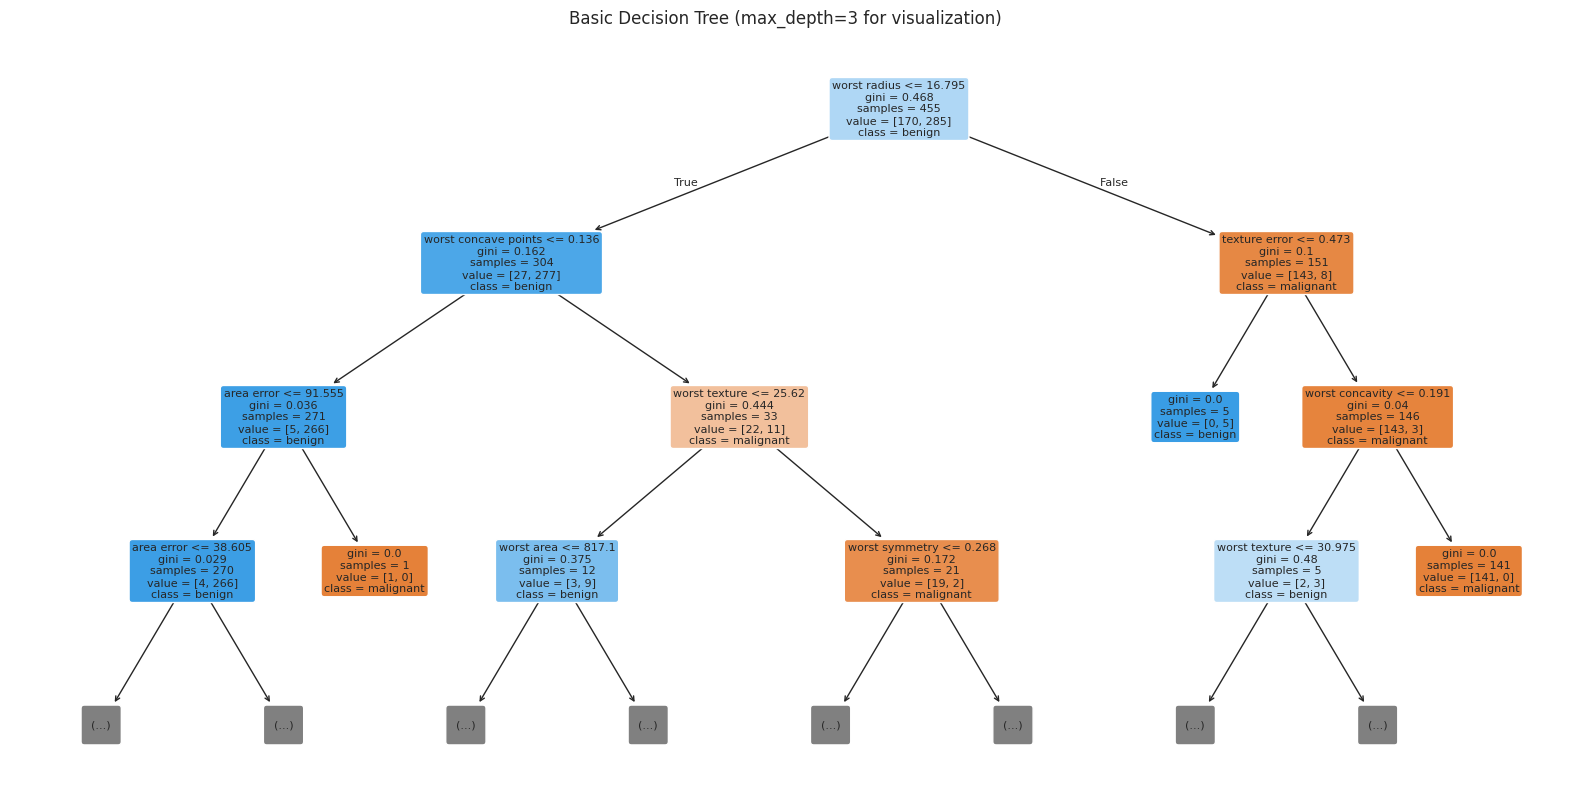

In [ ]:
# Let's visualize the basic tree (limiting depth for readability)
plt.figure(figsize=(20, 10))
plot_tree(dt_basic,
          feature_names=cancer.feature_names,
          class_names=cancer.target_names,
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3) # Only show first 3 levels
plt.title('Basic Decision Tree (max_depth=3 for visualization)')
plt.show()

In [ ]:
# Example: Decision Tree with max_depth=5
dt_depth5 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_depth5.fit(X_train, y_train)
y_pred_dt_depth5 = dt_depth5.predict(X_test)
accuracy_dt_depth5 = accuracy_score(y_test, y_pred_dt_depth5)
print(f"Decision Tree (max_depth=5) Accuracy: {accuracy_dt_depth5:.4f}")

# Example: Decision Tree with min_samples_leaf=10
dt_min_leaf10 = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
dt_min_leaf10.fit(X_train, y_train)
y_pred_dt_min_leaf10 = dt_min_leaf10.predict(X_test)
accuracy_dt_min_leaf10 = accuracy_score(y_test, y_pred_dt_min_leaf10)
print(f"Decision Tree (min_samples_leaf=10) Accuracy: {accuracy_dt_min_leaf10:.4f}")

# You can try other combinations and see how they affect accuracy!

Decision Tree (max_depth=5) Accuracy: 0.9211
Decision Tree (min_samples_leaf=10) Accuracy: 0.9474


### 2.3 Exercise: Tune a Decision Tree

**Teaching Notes:**
- **`GridSearchCV`:** Introduce `GridSearchCV` as a systematic way to explore parameter combinations. Explain `cv` (cross-validation) for robust evaluation and `n_jobs=-1` for parallel processing.
- **Interpreting Results:** Guide students on how to interpret `best_params_` and `best_score_`. Emphasize that `best_score_` is the cross-validation score, and the final test accuracy should be evaluated on the held-out test set.
- **Trade-offs:** Discuss the trade-off between model complexity (e.g., deeper trees) and generalization ability. A slightly lower training accuracy with better test accuracy is often preferred.

Try to find a combination of `max_depth`, `min_samples_split`, and `min_samples_leaf` that gives a good balance between training and testing accuracy. You can use `GridSearchCV` to help you!

**Model Solution:**

### 2.3 Exercise: Tune a Decision Tree

Try to find a combination of `max_depth`, `min_samples_split`, and `min_samples_leaf` that gives a good balance between training and testing accuracy. You can use `GridSearchCV` to help you!

In [ ]:
# Exercise: Implement GridSearchCV for Decision Tree
# Define a parameter grid
param_grid_dt = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Create a GridSearchCV object
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search to the training data
grid_search_dt.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters: {grid_search_dt.best_params_}")
print(f"Best cross-validation score: {grid_search_dt.best_score_:.4f}")

# Evaluate the best model on the test set
best_dt = grid_search_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)
accuracy_best_dt = accuracy_score(y_test, y_pred_best_dt)
print(f"Test accuracy of best Decision Tree: {accuracy_best_dt:.4f}")

Best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-validation score: 0.9385
Test accuracy of best Decision Tree: 0.9211


## 3. Random Forests for Classification

**Teaching Notes:**
- **Ensemble Learning:** Introduce Random Forests as a prime example of ensemble learning, specifically **Bagging** (Bootstrap Aggregating). Explain that it builds many trees independently and averages their predictions.
- **Benefits:** Highlight the key advantages: reduced overfitting (due to averaging), improved accuracy, and inherent feature importance calculation.
- **Analogy:** Think of it as getting opinions from many diverse experts (trees) and combining them to make a more robust decision.


## 3. Random Forests for Classification

Random Forests are an ensemble method that builds multiple decision trees and combines their predictions. This often leads to better performance and less overfitting than a single decision tree.

### 3.1 Basic Random Forest

Let's train a `RandomForestClassifier` with default settings.

In [ ]:
# Initialize a basic Random Forest Classifier
rf_basic = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_basic.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf_basic = rf_basic.predict(X_test)

# Evaluate the model
accuracy_rf_basic = accuracy_score(y_test, y_pred_rf_basic)
print(f"Basic Random Forest Accuracy: {accuracy_rf_basic:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_basic, target_names=cancer.target_names))

Basic Random Forest Accuracy: 0.9561

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### 3.2 Exploring Key Parameters of Random Forests

**Teaching Notes:**
- **`n_estimators`:** Explain that more trees generally improve performance up to a point, but with diminishing returns and increased computational cost. It's a balance.
- **`max_features`:** This is crucial for decorrelating the trees. Explain `"sqrt"` (default for classification) and `"log2"` as common strategies. This ensures each tree sees a slightly different subset of features, promoting diversity.
- **`oob_score`:** Explain Out-of-Bag (OOB) samples as a "free" validation set. Samples not used to train a particular tree can be used to estimate its performance, providing an internal cross-validation score without needing a separate validation set.
- **Common Pitfall:** Students might set `max_features` too high (e.g., `None`), making trees too similar and reducing the ensemble's benefit. Or they might use too few `n_estimators`, not fully leveraging the ensemble power.


### 3.2 Exploring Key Parameters of Random Forests

Random Forests have several important parameters:

- `n_estimators`: The number of trees in the forest. More trees generally lead to better performance but take longer to train.
- `max_depth`: The maximum depth of each tree in the forest. Similar to Decision Trees, it controls individual tree complexity.
- `max_features`: The number of features to consider when looking for the best split. Can be an integer, float, or `"sqrt"` (square root of total features) or `"log2"` (log base 2 of total features). This introduces randomness and reduces correlation between trees.
- `oob_score`: Whether to use out-of-bag samples to estimate the generalization accuracy. OOB samples are those not used in the bootstrap sample for a given tree.

In [ ]:
# Example: Random Forest with fewer estimators
rf_n50 = RandomForestClassifier(n_estimators=50, random_state=42)
rf_n50.fit(X_train, y_train)
accuracy_rf_n50 = accuracy_score(y_test, rf_n50.predict(X_test))
print(f"Random Forest (n_estimators=50) Accuracy: {accuracy_rf_n50:.4f}")

# Example: Random Forest with max_features='log2'
rf_log2 = RandomForestClassifier(n_estimators=100, max_features='log2', random_state=42)
rf_log2.fit(X_train, y_train)
accuracy_rf_log2 = accuracy_score(y_test, rf_log2.predict(X_test))
print(f"Random Forest (max_features='log2') Accuracy: {accuracy_rf_log2:.4f}")

# Check OOB Score (if enabled)
if rf_basic.oob_score:
    print(f"\nRandom Forest OOB Score: {rf_basic.oob_score_:.4f}")

Random Forest (n_estimators=50) Accuracy: 0.9561


Random Forest (max_features='log2') Accuracy: 0.9561


### 3.3 Feature Importance with Random Forests

**Teaching Notes:**
- **Interpretation:** Explain that feature importance in Random Forests is typically based on how much each feature reduces impurity (Gini or entropy) across all trees in the forest. The values are normalized.
- **Caveats:** Mention that these importances can sometimes be biased towards correlated features or features with many unique values. Introduce the idea of Permutation Importance as a more robust alternative (though not implemented here, it's a good discussion point).
- **Actionable Insights:** Emphasize that feature importance helps in understanding the data and potentially for feature selection in future models.


### 3.3 Feature Importance with Random Forests

Random Forests can also tell us which features were most important for making predictions.

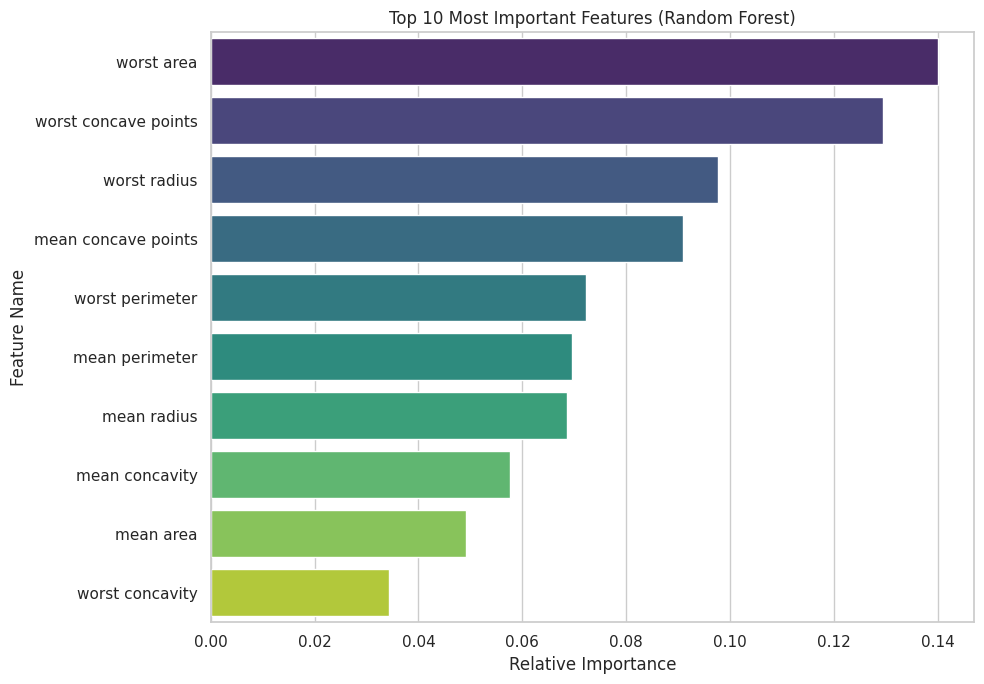

In [ ]:
# Get feature importances
feature_importances = rf_basic.feature_importances_
features_df = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### 3.4 Exercise: Tune a Random Forest

**Teaching Notes:**
- **Computational Cost:** Remind students that tuning Random Forests, especially `n_estimators`, can be computationally intensive. Discuss strategies like starting with a smaller `n_estimators` range or using `RandomizedSearchCV` for larger search spaces.
- **Impact of Parameters:** Guide them to observe how `max_depth` affects individual tree complexity and `max_features` affects tree diversity, both contributing to the overall forest performance.

Experiment with `n_estimators`, `max_depth`, and `max_features` to see how they affect the model's performance. Can you beat the default Random Forest accuracy?

**Model Solution:**

### 3.4 Exercise: Tune a Random Forest

Experiment with `n_estimators`, `max_depth`, and `max_features` to see how they affect the model's performance. Can you beat the default Random Forest accuracy?

In [ ]:
# Exercise: Implement GridSearchCV for Random Forest
# Define a parameter grid
param_grid_rf_ex = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2']
}

# Create a GridSearchCV object
grid_search_rf_ex = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf_ex, cv=3, scoring='accuracy', n_jobs=-1)

# Fit the grid search to the training data
grid_search_rf_ex.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters: {grid_search_rf_ex.best_params_}")
print(f"Best cross-validation score: {grid_search_rf_ex.best_score_:.4f}")

# Evaluate the best model on the test set
best_rf_ex = grid_search_rf_ex.best_estimator_
y_pred_best_rf_ex = best_rf_ex.predict(X_test)
accuracy_best_rf_ex = accuracy_score(y_test, y_pred_best_rf_ex)
print(f"Test accuracy of best Random Forest: {accuracy_best_rf_ex:.4f}")

Best parameters: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 150}
Best cross-validation score: 0.9582
Test accuracy of best Random Forest: 0.9474


## 4. Boosting Methods for Classification

**Teaching Notes:**
- **Sequential Learning:** The core concept of boosting is sequential learning, where each new model tries to correct the errors of the previous ones. This is a key differentiator from bagging.
- **Weak Learners:** Explain that boosting typically uses "weak learners" (often shallow decision trees, sometimes called "stumps") that are just slightly better than random guessing. The power comes from combining many of them.
- **Bias-Variance Trade-off:** Boosting primarily aims to reduce bias, while bagging (Random Forest) primarily aims to reduce variance.


## 4. Boosting Methods for Classification

Boosting is another powerful ensemble technique where models are built sequentially. Each new model tries to correct the errors made by the previous ones. We'll look at three popular boosting algorithms: AdaBoost, Gradient Boosting, and XGBoost.

In [ ]:
# 4.1 AdaBoost Classifier
print("\n--- AdaBoost Classifier ---")
ada_clf = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_test)
accuracy_ada = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost Accuracy: {accuracy_ada:.4f}")
print(classification_report(y_test, y_pred_ada, target_names=cancer.target_names))


--- AdaBoost Classifier ---


AdaBoost Accuracy: 0.9561
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### 4.1 AdaBoost (Adaptive Boosting)

**Teaching Notes:**
- **Weighting Samples:** Explain how AdaBoost adaptively changes the weights of training samples, giving more importance to misclassified samples in subsequent iterations.
- **Decision Stumps:** Often uses `DecisionTreeClassifier(max_depth=1)` as its base estimator. This makes it easy to visualize how it focuses on errors.
- **Strengths/Weaknesses:** Good for simple, clear patterns. Can be sensitive to noisy data and outliers because it focuses heavily on misclassified points.
- **Common Pitfall:** Using too many estimators with a complex base learner can lead to overfitting.


### 4.1 AdaBoost (Adaptive Boosting)

AdaBoost combines multiple "weak" learners (often shallow decision trees) to create a strong learner. It focuses on samples that were misclassified by previous learners.

In [ ]:
# 4.2 Gradient Boosting Classifier
print("\n--- Gradient Boosting Classifier ---")
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {accuracy_gb:.4f}")
print(classification_report(y_test, y_pred_gb, target_names=cancer.target_names))


--- Gradient Boosting Classifier ---


Gradient Boosting Accuracy: 0.9561
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### 4.2 Gradient Boosting

**Teaching Notes:**
- **Residuals:** Explain the concept of predicting residuals (errors). Each new tree tries to predict the difference between the actual target and the current ensemble's prediction.
- **`learning_rate`:** This is a critical parameter. A smaller learning rate means each tree contributes less, requiring more `n_estimators` but often leading to a more robust model. It's a shrinkage parameter.
- **Flexibility:** Mention that Gradient Boosting is very flexible because it can optimize any differentiable loss function.
- **Common Pitfall:** Can be slow to train and prone to overfitting if `learning_rate` is too high or `n_estimators` is too large without proper regularization.


### 4.2 Gradient Boosting

Gradient Boosting builds trees sequentially, where each new tree tries to predict the "residuals" (errors) of the previous trees. It's a very powerful and flexible algorithm.

In [ ]:
# 4.3 XGBoost Classifier
print("\n--- XGBoost Classifier ---")
xgb_clf = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=cancer.target_names))


--- XGBoost Classifier ---
XGBoost Accuracy: 0.9474
              precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



### 4.3 XGBoost (Extreme Gradient Boosting)

**Teaching Notes:**
- **Optimization:** Highlight that XGBoost is an optimized, highly efficient, and scalable implementation of gradient boosting. It's not a new algorithm but an engineering marvel.
- **Regularization:** Mention its built-in regularization (L1 and L2) which helps prevent overfitting, a common issue with traditional Gradient Boosting.
- **Popularity:** Explain its widespread use and success in Kaggle competitions due to its speed, performance, and robust handling of various data types.
- **Parameters:** Note that it has many parameters, offering fine-grained control but also making tuning more complex.
- **`use_label_encoder=False` and `eval_metric`:** Explain these are often needed to suppress warnings in newer XGBoost versions.


### 4.3 XGBoost (Extreme Gradient Boosting)

XGBoost is an optimized and highly efficient implementation of gradient boosting. It's known for its speed and performance, especially in competitive machine learning.

In [ ]:
# Exercise: Experiment with Boosting Parameters
# Try changing n_estimators and learning_rate for each boosting model.
# For example, for AdaBoost:
print("\n--- Tuned AdaBoost Classifier ---")
ada_clf_tuned = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42)
ada_clf_tuned.fit(X_train, y_train)
accuracy_ada_tuned = accuracy_score(y_test, ada_clf_tuned.predict(X_test))
print(f"Tuned AdaBoost Accuracy: {accuracy_ada_tuned:.4f}")

# For Gradient Boosting:
print("\n--- Tuned Gradient Boosting Classifier ---")
gb_clf_tuned = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb_clf_tuned.fit(X_train, y_train)
accuracy_gb_tuned = accuracy_score(y_test, gb_clf_tuned.predict(X_test))
print(f"Tuned Gradient Boosting Accuracy: {accuracy_gb_tuned:.4f}")

# For XGBoost:
print("\n--- Tuned XGBoost Classifier ---")
xgb_clf_tuned = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_clf_tuned.fit(X_train, y_train)
accuracy_xgb_tuned = accuracy_score(y_test, xgb_clf_tuned.predict(X_test))
print(f"Tuned XGBoost Accuracy: {accuracy_xgb_tuned:.4f}")



--- Tuned AdaBoost Classifier ---


Tuned AdaBoost Accuracy: 0.9561

--- Tuned Gradient Boosting Classifier ---


Tuned Gradient Boosting Accuracy: 0.9561

--- Tuned XGBoost Classifier ---
Tuned XGBoost Accuracy: 0.9474
